# L5. Teaching It to See

The device learns something new by writing example vectors to memory: no retraining, no fine-tuning. Pick a subject, give it a name, and teach it yourself. Then everything you built lands in one assistant that answers questions about your day and recognizes what you taught it, offline.

## 1. Choose the subject to teach

Pick one object you have with you. Upload two or more photos of it on the left, taken from different angles or in different places. Upload one more photo on the right. That last photo is held back so the device meets it once before teaching and once after. Skip the upload to use the bundled rubber duck.

In [1]:
from helper import *

MY_LABEL = "rubber duck"      # the name it learns

# What it should remember about your subject, and how you'll ask for it.
MY_NOTE = "Rubber duck for the bath, from the toy shop on Elm Street"
MY_QUESTION = "what did I get at the toy shop?"

photo_uploader()

## 2. Create an object-memory shard

In [2]:
from qdrant_edge import EdgeShard, Point, UpdateOperation

object_shard = new_shard("./object_shard", image=512)

teach_photos, test_photo = object_photos()
print(f'Teaching "{MY_LABEL}"')

Shard ready: image 512-d (CLIP)
Bundled example: rubber duck, 2 to teach with, 1 to test
Teaching "rubber duck"


## 3. Store the first object memories


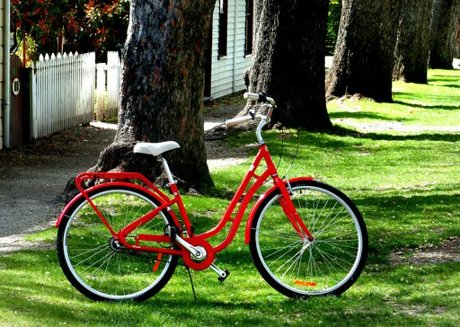
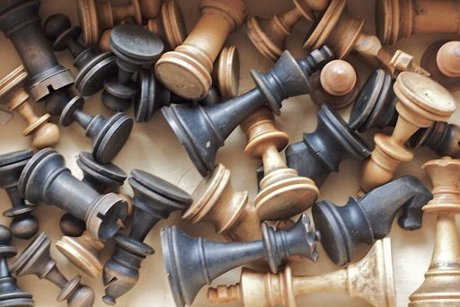
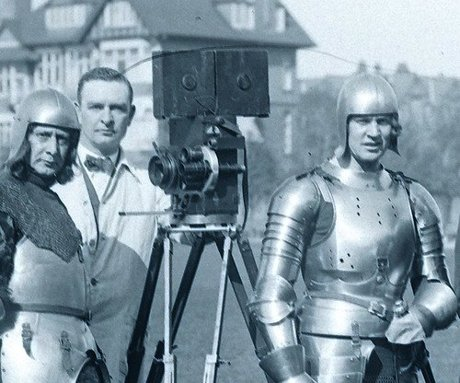

In [3]:
def teach(shard, label, view_paths, start_id):
    vectors = embed_image(view_paths)
    points = [
        Point(id=start_id + i, vector={"image": vector},
              payload={"label": label, "file": path})
        for i, (path, vector) in enumerate(zip(view_paths, vectors))
    ]
    shard.update(UpdateOperation.upsert_points(points))
    shard.optimize()
    # flush to disk now: a taught memory should survive a power cut
    shard.flush()


seed_objects(object_shard)

## 4. Search before teaching

Nearest search always returns something. Before teaching, the closest stored memory is still another object.


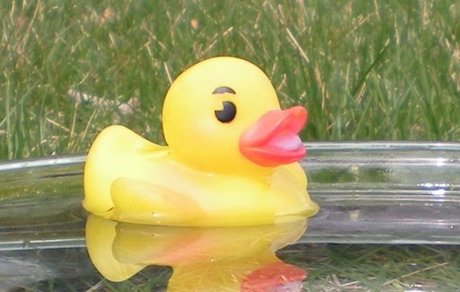
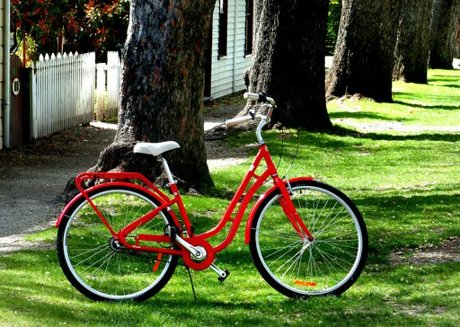

In [4]:
top, _ = recognize(object_shard, test_photo)
recognition_result(test_photo, top, known=None, expected=MY_LABEL)

## 5. Teach it, find it

Retrieval comes first: the held-out photo finds the right memory before any threshold decides whether to accept it.


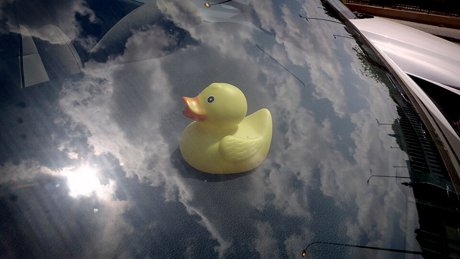
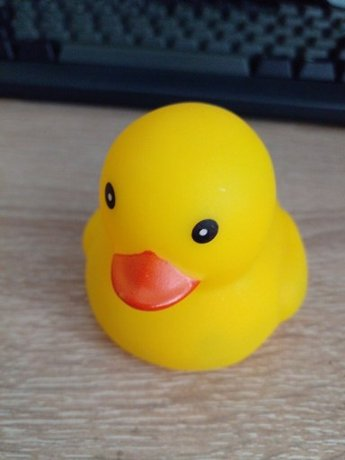

In [5]:
teach(object_shard, MY_LABEL, teach_photos, start_id=100)
caption = f'Taught "{MY_LABEL}" from {len(teach_photos)} photos'
show_images(teach_photos, title=caption)


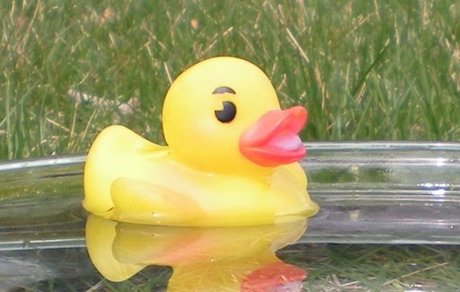
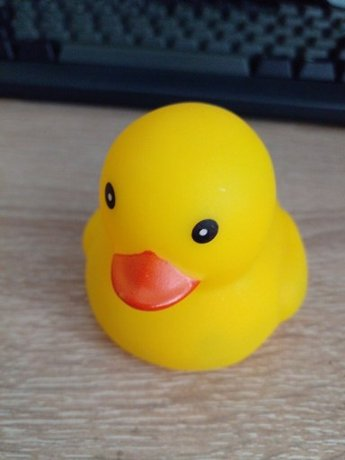

In [6]:
top, _ = recognize(object_shard, test_photo)
recognition_result(test_photo, top, known=None, expected=MY_LABEL)

## 6. Calibrate recognition with held-out photos

Each object keeps one view out of its teaching set, so these scores measure real recognition.

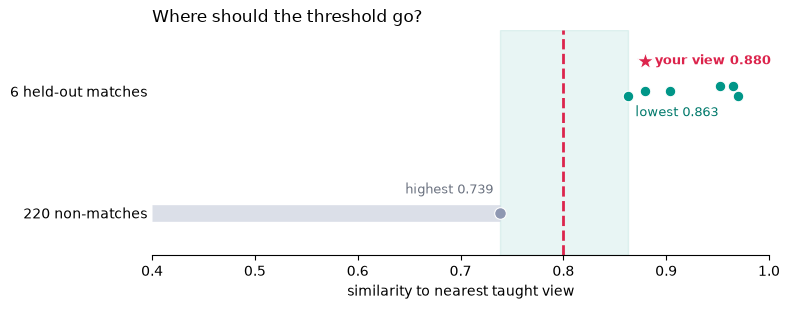


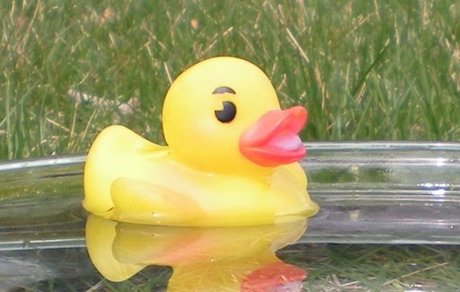
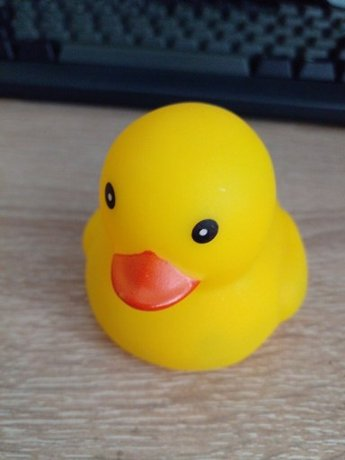

In [7]:
# Pick a value between the tested non-matches and matches.
RECOGNIZE_THRESHOLD = 0.80

threshold_calibration(
    "./ro_shared_data/objects",
    "./ro_shared_data/images",
    selected=RECOGNIZE_THRESHOLD,
    current=(MY_LABEL, top.score),
)

top, known = recognize(object_shard, test_photo,
                       RECOGNIZE_THRESHOLD)
recognition_result(
    test_photo, top, known,
    threshold=RECOGNIZE_THRESHOLD, expected=MY_LABEL,
)

## 7. Assemble the assistant

In [8]:
ASSISTANT_DIR = "./assistant_shard"
assistant_shard = new_shard(ASSISTANT_DIR, text=768, image=512)

day, history, notes, photos = load_day_and_history()
store_notes(assistant_shard, notes, preview=False)
store_photo_memories(assistant_shard, photos,
                     "./ro_shared_data/images", preview=False)

Shard ready: text 768-d (Nomic), image 512-d (CLIP)


Stored 127 notes


Stored 17 photos · 144 memories


In [9]:
photo_vector = embed_image([teach_photos[0]])[0]
note_vector = embed_text([MY_NOTE])[0]

# One memory, two ways in: the photo's vector and the note's, one point.
my_memory = Point(
    id=5000,
    vector={"image": photo_vector, "text": note_vector},
    payload={"label": MY_LABEL, "file": teach_photos[0],
             "note": MY_NOTE},
)
assistant_shard.update(UpdateOperation.upsert_points([my_memory]))
assistant_shard.optimize()
assistant_shard.flush()

receipt_table([
    ("today", f"{len(day)} captures"),
    ("history", f"{len(history)} notes"),
    ("taught", f"{MY_LABEL}: photo + note"),
    ("total", f"{assistant_shard.info().points_count} memories"),
], title="Your assistant's memory")

,
today,42 captures
history,102 notes
taught,rubber duck: photo + note
total,145 memories


## 8. Rank by meaning and freshness

Your assistant holds three weeks of memories, so a question can match a fact that a later memory replaced. A freshness term added to the score brings the newer memory to the top and keeps the older one in view.

In [10]:
question = "gym locker code"

by_meaning = text_search(assistant_shard, question, limit=3)

results_table(by_meaning, "By meaning alone",
              query=question, when=True, price=False)

Score,Category,When,Memory
0.809,health,Oct 30,"Quick memo, locker code at the gym is 2280"
0.791,health,Nov 14,"Renewed the gym membership, locker code is 4471"
0.593,health,Nov 08,"Gym session, cardio and weights"


In [11]:
from qdrant_edge import (DecayKind, Expression, Formula,
                         Prefetch, Query, QueryRequest)

NEWEST = max(m["timestamp"] for m in day)
HALF_LIFE = 7 * 86400   # a memory a week old counts about half
WEIGHT = 0.2            # how much freshness can move a score

freshness = Expression.Decay(
    DecayKind.Exp,
    Expression.Variable("timestamp"),
    target=Expression.Constant(NEWEST),
    midpoint=0.5,
    scale=HALF_LIFE,
)
recency = Formula(Expression.Sum([
    Expression.Variable("$score"),
    Expression.Mult([Expression.Constant(WEIGHT), freshness]),
]))

In [12]:
question_vector = embed_query(question)

hits = assistant_shard.query(QueryRequest(
    limit=3,
    prefetches=[Prefetch(
        limit=20,
        query=Query.Nearest(question_vector, using="text"),
    )],
    query=recency,
    with_payload=True,
))

results_table(hits, "By meaning and freshness",
              query=question, when=True, price=False)

Score,Category,When,Memory
0.980,health,Nov 14,"Renewed the gym membership, locker code is 4471"
0.854,health,Oct 30,"Quick memo, locker code at the gym is 2280"
0.702,health,Nov 08,"Gym session, cardio and weights"


## 9. Ask your assistant

You asked,It remembered,Words,When,Photo
what did I get at the toy shop?,"Rubber duck for the bath, from the toy shop on Elm Street",0.659,you taught this,0.238✅ same memory
show me the bakery,New bakery on the corner does an amazing morning cronut,0.658,Nov 14,0.253
where did I have brunch,"Brunch at the cafe, pancakes and coffee, $14",0.671,Nov 08,0.222
what did the bike chain cost,"Bought new bike chain, $32 at station shop",0.809,Nov 12,0.249

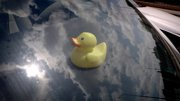
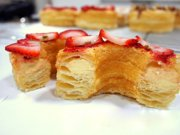
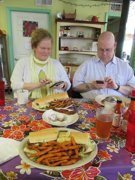
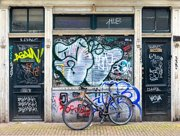

In [13]:
assistant_shard.close()
assistant_shard = EdgeShard.load(ASSISTANT_DIR)

# Add your own questions to this list and re-run.
questions = [MY_QUESTION,
             "show me the bakery",
             "where did I have brunch",
             "what did the bike chain cost"]

answers = []
for question in questions:
    words = text_search(assistant_shard, question, limit=1)[0]
    picture = photo_search(assistant_shard, question, limit=1)[0]
    answers.append((question, words, picture))

answers_table(answers, "./ro_shared_data/images")

## Where this goes

The rule you just built is the one the robot from Lesson 2 runs on real hardware: embed what the camera sees, find the nearest taught view, and compare that one score against one threshold.

Its threshold is 0.90 where yours is 0.80, and the difference is the camera rather than the code. Every crop from one camera shares the same lighting, sensor, background, and scale, so unrelated objects score high together and the whole range shifts up. A score measures how closely two vectors point the same way, which is why 0.90 does not mean 90% confident.

The robot calibrates the way you just did, on held-out photos of its own objects. When the two ranges overlap, no threshold separates them, and the fix is a closer or better lit view rather than a different number. Teaching an object again adds a view instead of replacing one, which is how it comes to recognize something from more angles.